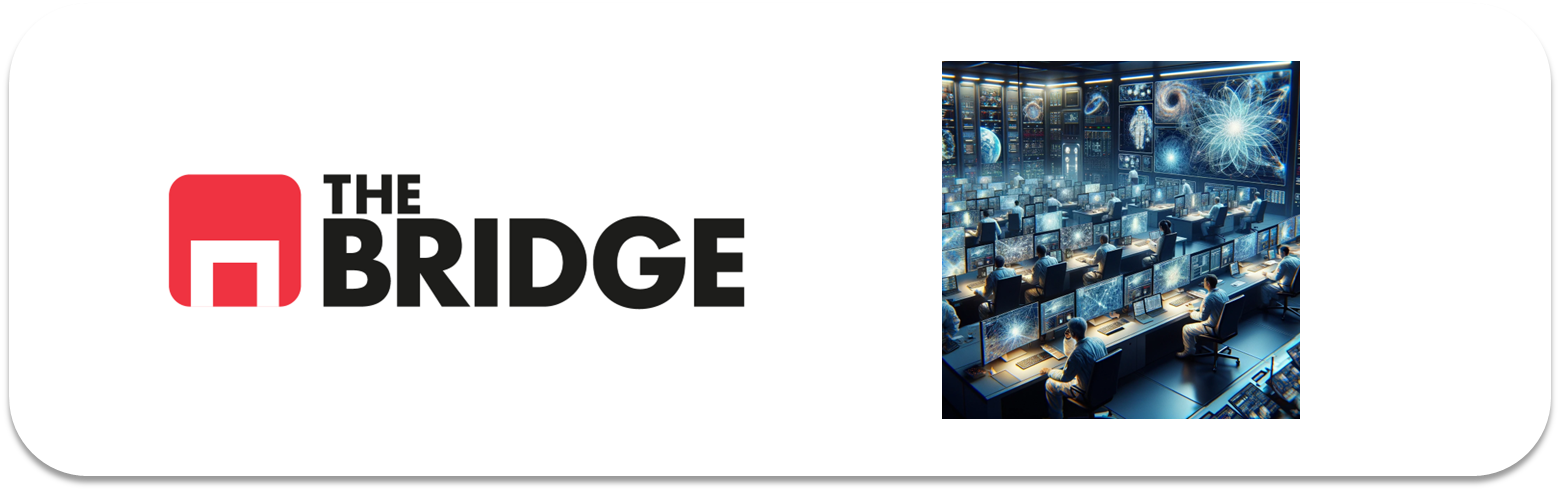

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from bootcampviztools import pinta_distribucion_categoricas
from keras.callbacks import EarlyStopping

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras.

In [ ]:
# 1.1. Función para leer imágenes
def cargar_imagenes(carpeta):
    imagenes = []
    clases = []

    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        imagen = cv2.imread(ruta)
        imagen = cv2.resize(imagen, (32,32))
        imagenes.append(imagen)

        if "dog" in archivo:
            clases.append(1)
        else:
            clases.append(0)
            
    return np.array(imagenes), np.array(clases)

In [41]:
# 1.2. Crear dataset de train
X_train_list = []
y_train_list = []
carpetas_train = [
    "./data/github_train_0",
    "./data/github_train_1",
    "./data/github_train_2",
    "./data/github_train_3",
]

for carpeta in carpetas_train:
    X_temp, y_temp = cargar_imagenes(carpeta)
    X_train_list.append(X_temp)
    y_train_list.append(y_temp)

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

In [42]:
# 1.3. Crear dataset de test
X_test, y_test = cargar_imagenes("./data/github_test")

In [43]:
# 1.4. Comprobar que todo está ok
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4000, 32, 32, 3)
(4000,)
(1000, 32, 32, 3)
(1000,)


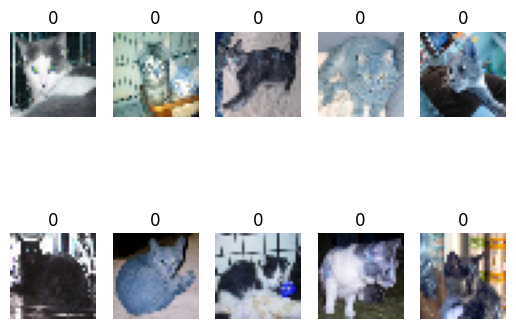

In [44]:
# 2.1. Visualizar algunas imágenes
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

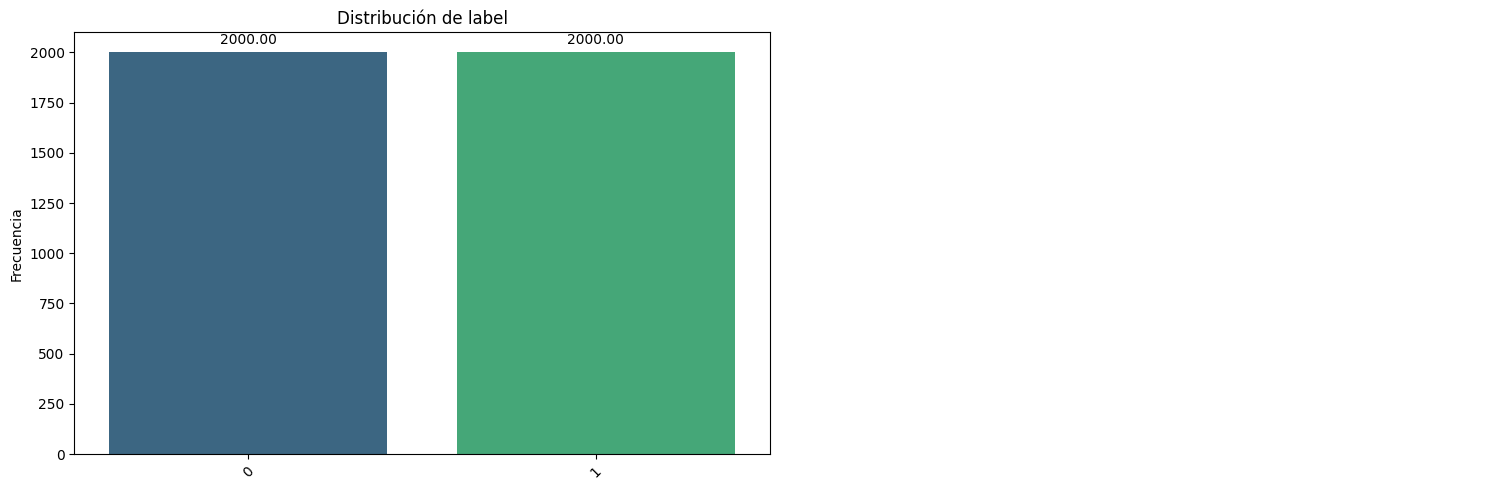

In [45]:
# 2.2. Distribución de clases
df_train = pd.DataFrame({
    "label": y_train
})

pinta_distribucion_categoricas(df_train, ["label"], relativa=False, mostrar_valores=True)

In [46]:
# 2.3. Escalar valores
X_train = X_train / 255
X_test = X_test / 255

In [47]:
# 2.4. Construir modelo CNN
model = Sequential()
model.add(Conv2D(16, (3,3), activation="relu", input_shape=(32,32,3)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# 2.5. Compilar modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [49]:
# 2.6. Ver arquitectura del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,801 (596.88 KB)

 Trainable params: 152,801 (596.88 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# 3.1. Crear callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [51]:
# 3.2. Entrenar modelo
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6222 - loss: 0.6609 - val_accuracy: 0.0362 - val_loss: 1.0116
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6631 - loss: 0.6133 - val_accuracy: 0.1813 - val_loss: 1.0138
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7003 - loss: 0.5800 - val_accuracy: 0.2837 - val_loss: 1.0059
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7128 - loss: 0.5635 - val_accuracy: 0.6725 - val_loss: 0.6008
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7359 - loss: 0.5302 - val_accuracy: 0.5725 - val_loss: 0.6968
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7350 - loss: 0.5220 - val_accuracy: 0.6288 - val_loss: 0.6290
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7634 - loss: 0.4877 - val_accuracy: 0.6288 - val_loss: 0.6430


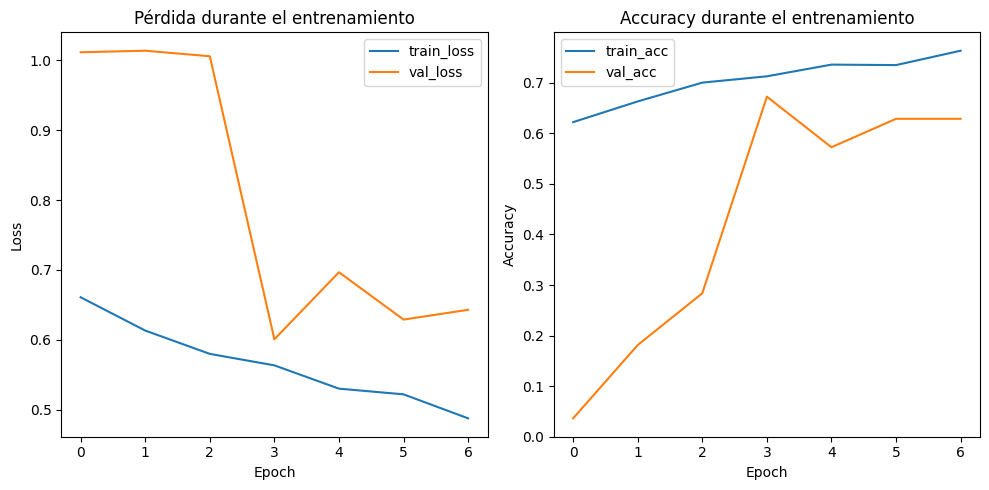

In [52]:
# 3.3. Graficar historial
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 4.1. Hacer predicciones
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [55]:
# 4.2. Classification Report
print(classification_report(y_test, y_pred, target_names=["cat", "dog"]))

              precision    recall  f1-score   support

         cat       0.68      0.70      0.69       500
         dog       0.69      0.66      0.68       500

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.68      0.68      1000



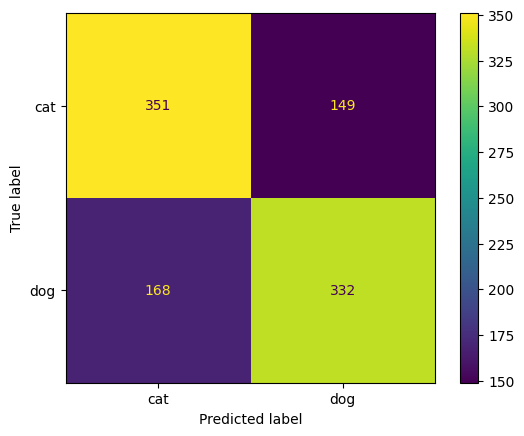

In [57]:
# 4.3. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["cat", "dog"])
plt.show()

In [58]:
# 5.1. Predicción de la clase
y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
# 5.2. Confianza de la predicción
confidence = np.where(y_pred == 1, y_pred_prob[:,0], 1 - y_pred_prob[:,0])

In [60]:
# 5.3. Buscar posiciones donde el modelo se equivocó pero con alta confianza
high_confidence_wrong_prediction = np.where((y_pred != y_test) & (confidence >= 0.7))[0]

In [63]:
# 5.4. Mostrar los errores
for i in high_confidence_wrong_prediction:
    print(f"Imagen {i} - Predicción = {y_pred[i]}, Realidad = {y_test[i]}, Confianza = {confidence[i]:.2f}")

Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Predicción = 1, Realidad = 1, Confianza = 0.64
Imagen 0 - Pre

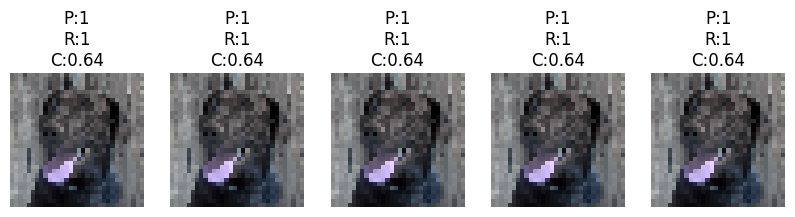

In [ ]:
# 5.5. Mostrar las imágenes de los errores
y_pred = y_pred.flatten()
y_test = y_test.flatten()
confidence = confidence.flatten()

plt.figure(figsize=(10,5))
for idx, i in enumerate(high_confidence_wrong_prediction[:5]):
    plt.subplot(1,5,idx+1)
    plt.imshow(X_test[i])
    plt.title(f"P:{y_pred[i]}\nR:{y_test[i]}\nC:{confidence[i]:.2f}")
    plt.axis("off")
plt.show()